# 同一力矩，不同肌肉答案：幾何、手算與求解器

配合 [逐步筆記](../notes.md)。請先手算可行線段，再執行程式。
本課使用兩條同向肌與合成參數；動畫是問題參數的變化，不是求解器迭代。

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
cwd = Path.cwd()
lesson = next(p / '06_optimization' for p in [cwd, *cwd.parents]
              if (p / '06_optimization' / 'src').is_dir())
sys.path.insert(0, str(lesson / 'src'))
from redundancy import TwoMuscles
from animation import make_keyframes, make_animation
model = TwoMuscles()
figures = lesson / 'figures'
figures.mkdir(exist_ok=True)
print('Feasible F1 interval:', model.interval(8), 'N')
print('Maximum torque:', model.capacity, 'N m')

Feasible F1 interval: (150.0, 200.0) N
Maximum torque: 14.0 N m


## 1. 平衡不等於唯一答案

$F_2=400-2F_1$。先猜以下三組中哪組違反上限，再核對。

In [2]:
for force in [np.array([160, 80]), np.array([190, 20]), np.array([100, 200])]:
    print('Force:', force, 'N; torque:', np.dot(model.arms, force),
          'N m; within bounds:', bool(np.all(force >= 0) and np.all(force <= model.limits)))
print('Nullspace check R n =', np.dot(model.arms, [1, -2]))

Force: [160  80] N; torque: 8.0 N m; within bounds: True
Force: [190  20] N; torque: 8.0 N m; within bounds: True
Force: [100 200] N; torque: 8.0 N m; within bounds: False
Nullspace check R n = 0.0


## 2. 不同目標選出不同解

在紙上推導
$F_1^0=w_2r_1\tau/(w_1r_2^2+w_2r_1^2)$，再限制在可行區間。
下方同時核對成熟求解器 SLSQP、平衡殘差與上下限。
請注意：`solve_numerically` 在 $z_i=F_i/U_i$ 座標求解，回傳值仍為 N。

In [3]:
for name, weights in [('Force squared', (1, 1)),
                       ('Activation squared', 1/np.array(model.limits)**2)]:
    analytic = model.solve(8, weights)
    numerical = model.solve_numerically(8, weights)
    residual = np.dot(model.arms, numerical) - 8
    print(name, '\n analytic:', analytic, '\n SLSQP:', numerical,
          '\n activation:', analytic / model.limits, '\n torque residual:', residual)
    np.testing.assert_allclose(numerical, analytic, atol=1e-5)
    assert abs(residual) < 1e-7
    assert np.all(numerical >= -1e-7) and np.all(numerical <= np.array(model.limits)+1e-7)

Force squared 
 analytic: [160.  80.] 
 SLSQP: [160.  80.] 
 activation: [0.53333333 0.8       ] 
 torque residual: 0.0
Activation squared 
 analytic: [194.59459459  10.81081081] 
 SLSQP: [194.59459459  10.81081081] 
 activation: [0.64864865 0.10810811] 
 torque residual: -8.881784197001252e-16


## 3. 上限與不可行性

12 N·m 時，沒有上限的力平方解為 $(240,120)$ N，但第二肌肉只能到 100 N。
16 N·m 則連可行解都不存在。程式應明確報錯，不把近似平衡當成成功。

In [4]:
print('12 N m solution:', model.solve(12))
print('14 N m solution:', model.solve(14))
try:
    model.solve(16)
except ValueError as error:
    print('Expected failure:', error)
else:
    raise AssertionError('An infeasible demand must not return an optimum.')

12 N m solution: [250. 100.]
14 N m solution: [300. 100.]
Expected failure: Infeasible torque: expected 0 <= torque <= 14 N m.


## 4. 幾何比較與動畫

先比較上排兩圖：可行線段相同，等高線不同。下排看能力上限與無解。
所有座標固定，星號是最佳點，藍線是可行集合。等高線為目標函數的等值集合，不是誤差範圍。

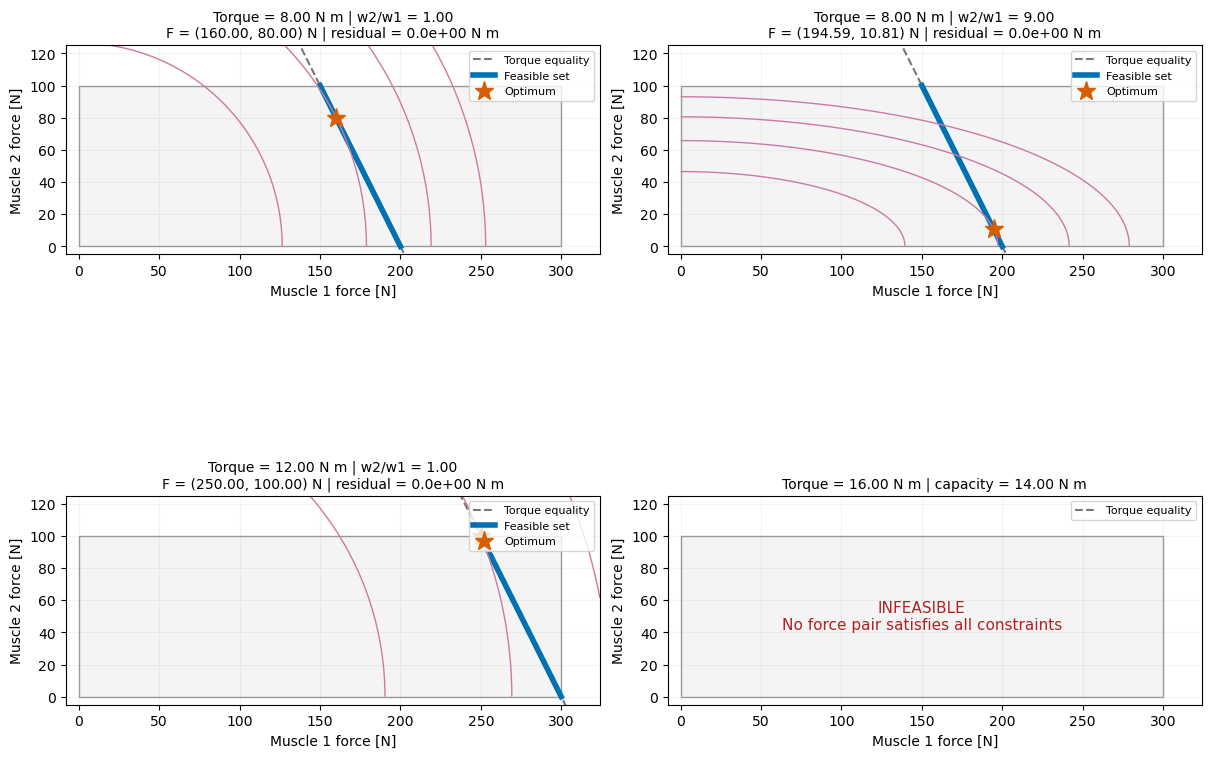

In [5]:
fig = make_keyframes(model)
fig.savefig(figures / 'redundancy_keyframes.png', dpi=120)
plt.show()

### 動畫 A：資料固定，選解偏好改變

需求固定 8 N·m，權重比由 1 增加到 9。暫停觀察星號沿線段移動。
比值 9 的目標與本例活化平方和相差正比例常數，因此有相同最適點。

In [6]:
def show_animation(mode):
    fig, animation = make_animation(model, mode)
    html = animation.to_jshtml(default_mode='once')
    plt.close(fig)
    (figures / f'{mode}_animation.html').write_text(
        '<!doctype html><html lang="zh-Hant"><meta charset="utf-8">'
        '<title>Muscle redundancy</title><body>'
        '<h1>肌肉冗餘與最佳化</h1><p>合成案例；這是問題參數變化，不是求解器迭代。</p>'
        + html + '</body></html>', encoding='utf-8')
    display(HTML(html))

show_animation('weights')

### 動畫 B：需求增加，直到沒有答案

目標固定為力平方和。需求從 0 增至 16 N·m，觀察上限何時介入。
14 N·m 只剩一個可行點；之後不再顯示最佳點。
若檢視器不允許 JavaScript，請在本機 Jupyter 執行或開啟 figures 中的 HTML。

In [7]:
show_animation('demand')

## 5. 用密集取樣獨立檢查，再提出問題

取樣只能提供數值比較，不能取代嚴格凸性的唯一性證明。回到筆記的二階導數推導。

In [8]:
grid = model.forces(np.linspace(*model.interval(8), 10001), 8)
for weights in [np.array([1, 1]), np.array([1, 9])]:
    best = model.solve(8, weights)
    analytic_cost = weights @ best**2
    sampled_cost = np.min(weights @ grid**2)
    print('weights:', weights, 'analytic:', analytic_cost, 'sampled:', sampled_cost)
    assert analytic_cost <= sampled_cost + 1e-8

weights: [1 1] analytic: 32000.0 sampled: 32000.0
weights: [1 9] analytic: 38918.91891891892 sampled: 38918.918925


請完成 [練習與參考解](../exercises/exercises.md)。最後用自己的話回答：
同一個力矩資料給出兩組不同的最佳答案時，我們新增了什麼假設？